Inspired by: https://github.com/timqqt/FinRL-Library/blob/master/FinRL_portfolio_allocation_NeurIPS_2020.ipynb

<a id='1.1'></a>
## 1. Install and import all packages:


In [1]:
# Uncomment if needed
#!pip install -r requirements.txt

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from finrl import config
from finrl.agents.stablebaselines3.models import DRLAgent
import gym
from gym import spaces
from stable_baselines3.common.vec_env import DummyVecEnv
from generators import UpwardTrendPriceGenerator, CashPriceGenerator
from environments import  StockPriceSimulator, StockPortfolioEnv
import os
from tabulate import tabulate

## Experiment 1

Define one stock with upward trend and cash:

In [3]:
# Define initial prices for stocks
initial_prices = {"UPWARD": 100, "CASH": 100}

# Define different price behaviors for each stock
generators = {
"UPWARD": UpwardTrendPriceGenerator(mean= 0.005, variance=0.09), 
"CASH": CashPriceGenerator()  # Cash remains constant
}

# Create the simulator
simulator = StockPriceSimulator(days=500, initial_prices=initial_prices, generators=generators)

# Generate stock prices
train = simulator.generate_prices()
train.head()

,date,tic,close,return_t-1,return_t-2,return_t-3,return_t-4,return_t-5
0,2023-01-06,CASH,100.0,0.0,0.0,0.0,0.0,0.0
1,2023-01-07,CASH,100.0,0.0,0.0,0.0,0.0,0.0
2,2023-01-08,CASH,100.0,0.0,0.0,0.0,0.0,0.0
3,2023-01-09,CASH,100.0,0.0,0.0,0.0,0.0,0.0
4,2023-01-10,CASH,100.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Check whethere there any inf values
num_df = train[['close', 'return_t-1', 'return_t-2', 'return_t-3', 'return_t-4', 'return_t-5']]
inf_rows = num_df[np.isinf(num_df).any(axis=1)]
print("Rows containing `inf` values:\n", inf_rows)

Rows containing `inf` values:
 Empty DataFrame
Columns: [close, return_t-1, return_t-2, return_t-3, return_t-4, return_t-5]
Index: []


Let's plot the upward trend of the stock:

In [5]:
# Define the full path for the image
folder_path = "Results/Experiment_1"
image_path = os.path.join(folder_path, "price_trend.png")

# Create the folder and sub-folder if they do not exist
os.makedirs(folder_path, exist_ok=True)

# Plot stock price
plt.figure(figsize=(12, 6))
for stock in train["tic"].unique():
    if stock != "CASH":
      stock_data = train[train["tic"] == stock]
      plt.plot(stock_data["date"], stock_data["close"], label=stock)

# Formatting the plot
plt.xlabel("Date")
plt.ylabel("Stock Price (Close)")
plt.title("Stock Price Trend")
plt.legend()
plt.grid(True)

# Plot the stock upward trend:
plt.savefig(image_path)

Define parameters for the env


In [ ]:
stock_dimension = len(train["tic"].unique())  # Count unique stocks
state_space = len(["close", "return_t-1", "return_t-2", "return_t-3", "return_t-4", "return_t-5"]) * stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")
env_kwargs = {
    "initial_amount": 100,
    "transaction_cost_pct": 0.01,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "past_returns": ["return_t-1", "return_t-2", "return_t-3", "return_t-4", "return_t-5"],
    "action_space": stock_dimension,
    "reward_scaling": 1,
    "reward_function": "sparse",
    "timestep_log":True
}

# Create the environment
e_train_gym = StockPortfolioEnv(df=train, **env_kwargs)

env_train, _ = e_train_gym.get_sb_env()

Stock Dimension: 2, State Space: 12
Resetting environment for Episode 0.
EPISODE:  0


/opt/anaconda3/envs/rl_project/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [7]:
# initialize the agent
agent = DRLAgent(env = env_train)
DDPG_PARAMS = {"batch_size": 128, "buffer_size": 50000, "learning_rate": 0.001}
model_ddpg = agent.get_model("ddpg",model_kwargs = DDPG_PARAMS)

{'batch_size': 128, 'buffer_size': 50000, 'learning_rate': 0.001}
Using cpu device


Define the number of episodes and days and train for episodes*day timesteps

In [8]:
episodes = 5
days = 500 
trained_ddpg = agent.train_model(model=model_ddpg,tb_log_name='ddpg',total_timesteps=episodes*days)

Resetting environment for Episode 1.

+----------------------------------------+---------------+
| Episode                                | 1             |
+----------------------------------------+---------------+
| Day                                    | 0             |
+----------------------------------------+---------------+
| Actions (weights before normalization) | [0.5, 0.5]    |
+----------------------------------------+---------------+
| Allocation weights                     | 0.50, 0.50    |
+----------------------------------------+---------------+
| Transaction Cost                       | 0.00          |
+----------------------------------------+---------------+
| Stock Returns                          | 0.00%, -1.59% |
+----------------------------------------+---------------+
| Portfolio Return                       | -0.80%        |
+----------------------------------------+---------------+
| Reward                                 | -0.00         |
+-----------------

In [9]:
e_train_gym.save_episode_log("Results/Experiment_1/training_logs_sparse.csv")

Saved episode log to Results/Experiment_1/training_logs_sparse.csv


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df_logs = pd.read_csv("training_logs.csv")

# Get unique episodes
episodes = df_logs["episode"].unique()
num_episodes = len(episodes)  # Total number of episodes

# Define function to plot `n` graphs
def plot_per_episode(df, metric, ylabel, title, filename):
    """Plot separate time series for each episode of a given metric."""
    fig, axes = plt.subplots(num_episodes, 1, figsize=(10, 4 * num_episodes), sharex=True)

    if num_episodes == 1:
        axes = [axes]  # Ensure axes is iterable for a single episode

    for idx, episode in enumerate(episodes):
        df_episode = df[df["episode"] == episode]
        axes[idx].plot(df_episode["day"], df_episode[metric], label=f"Episode {episode}", color="b")
        axes[idx].set_ylabel(ylabel)
        axes[idx].legend()
        axes[idx].set_title(f"{title} - Episode {episode}")

    plt.xlabel("Day")
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()  # Close figure to prevent excessive memory usage

# **1️⃣ Save Portfolio Value Plot**
plot_per_episode(df_logs, "new_portfolio_value", "Portfolio Value ($)", "Portfolio Value Time Series", "portfolio_value.png")

# **2️⃣ Save Portfolio Return Plot**
plot_per_episode(df_logs, "portfolio_return", "Portfolio Return (%)", "Portfolio Return Time Series", "portfolio_return.png")

# **3️⃣ Save Reward Plot**
plot_per_episode(df_logs, "reward", "Reward", "Reward Time Series", "reward.png")

# **4️⃣ Save Transaction Cost Plot**
plot_per_episode(df_logs, "transaction_cost", "Transaction Cost ($)", "Transaction Cost Time Series", "transaction_cost.png")

print("Plots saved as images.")




Plots saved as images.


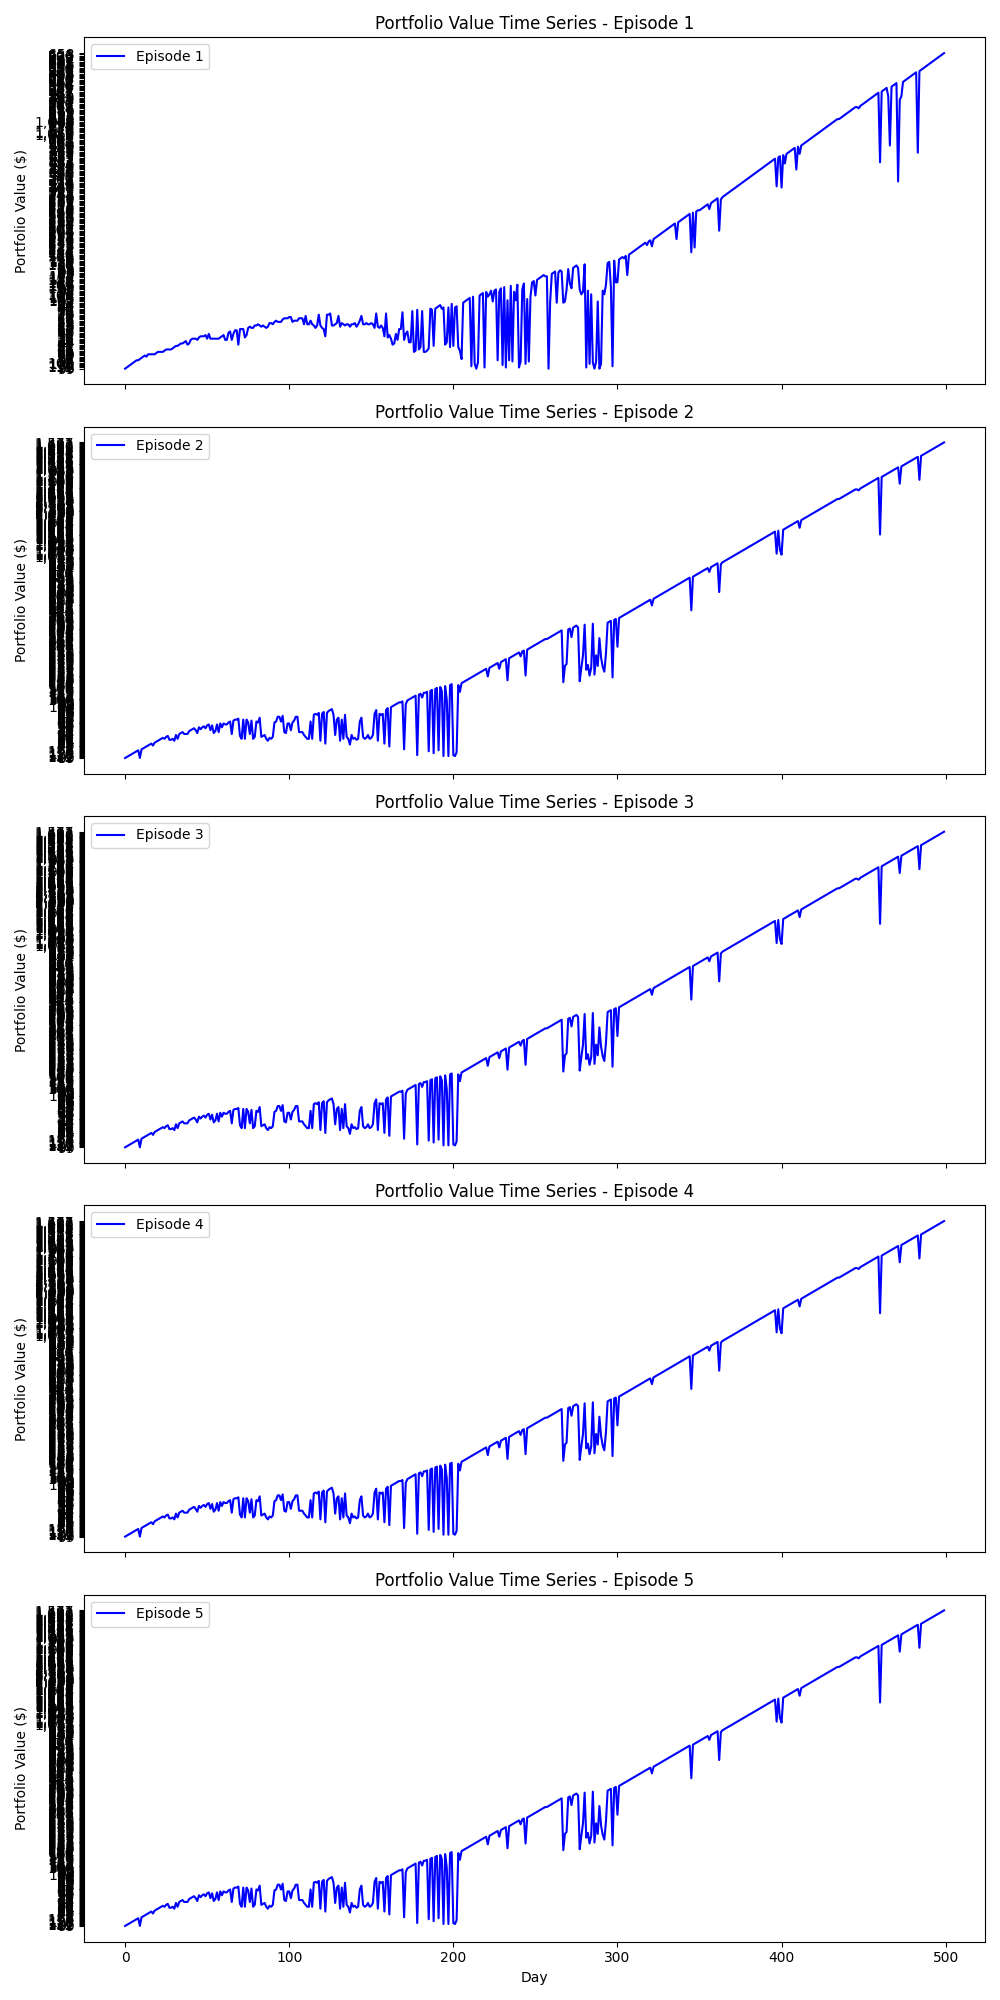

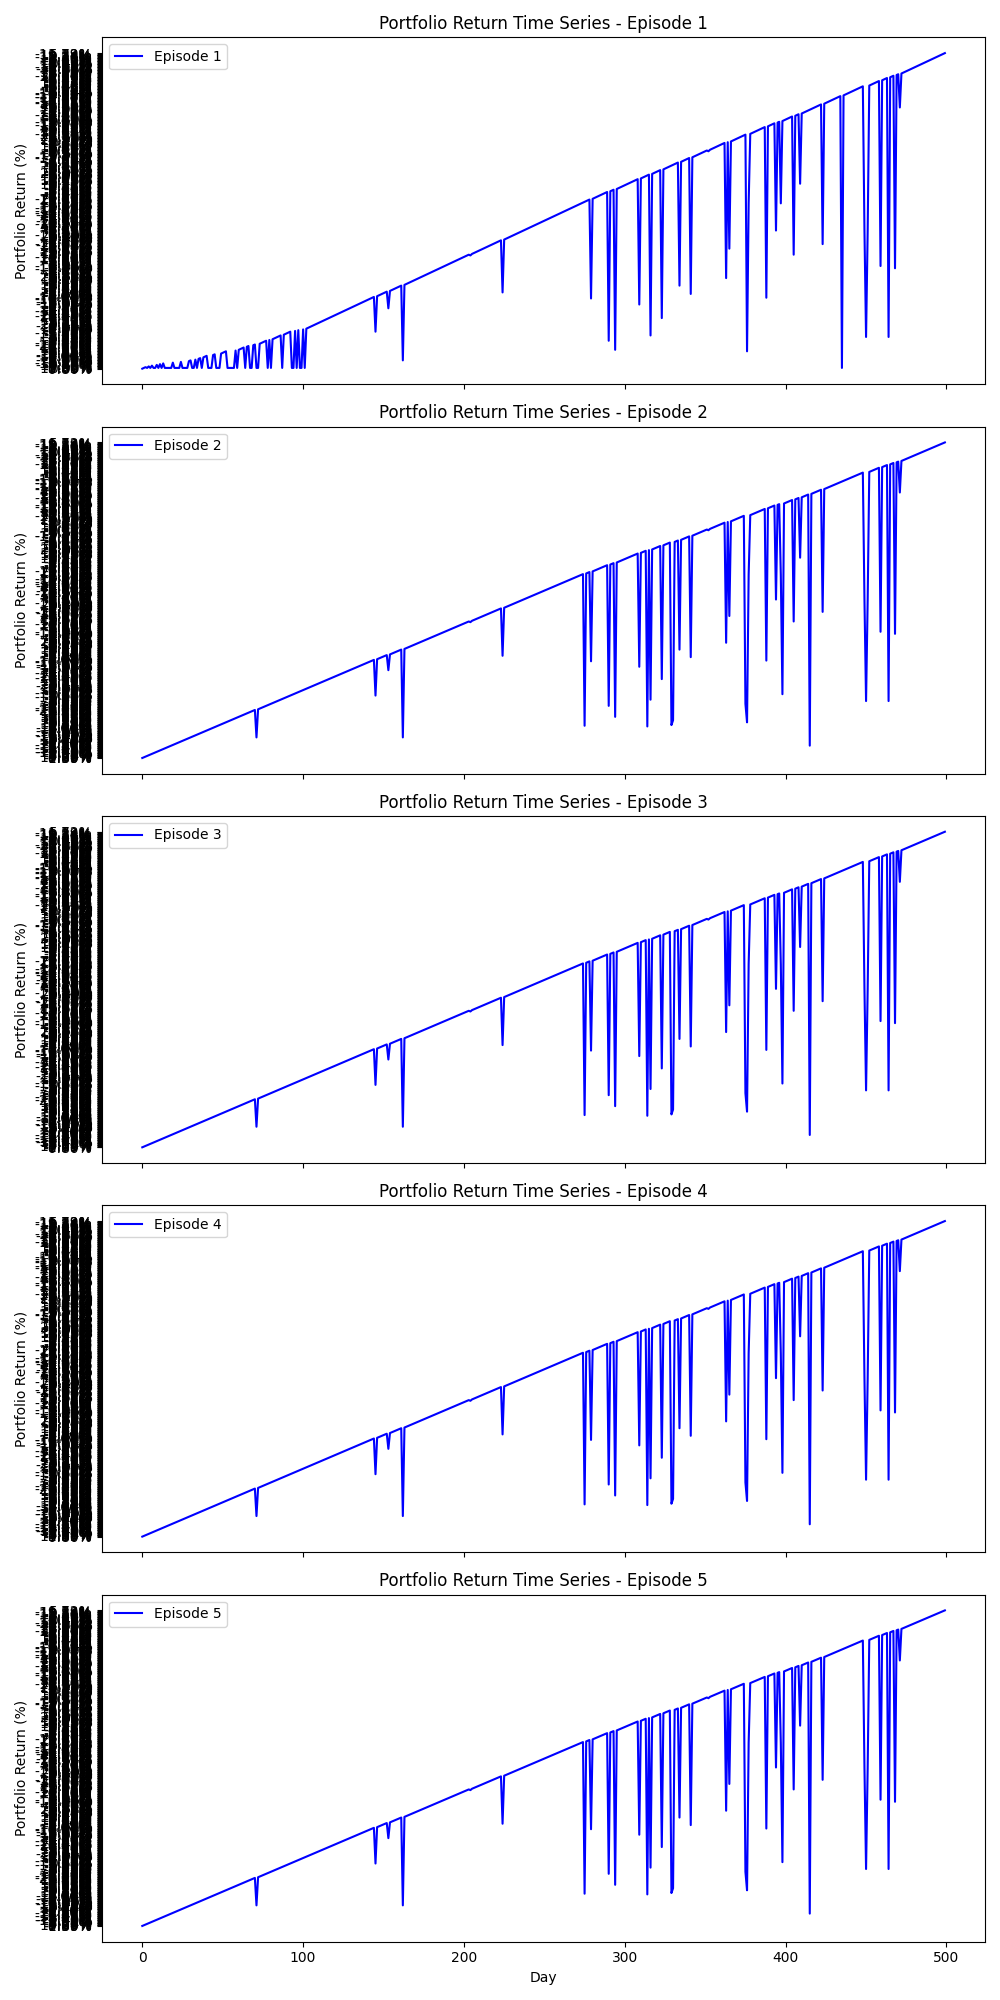

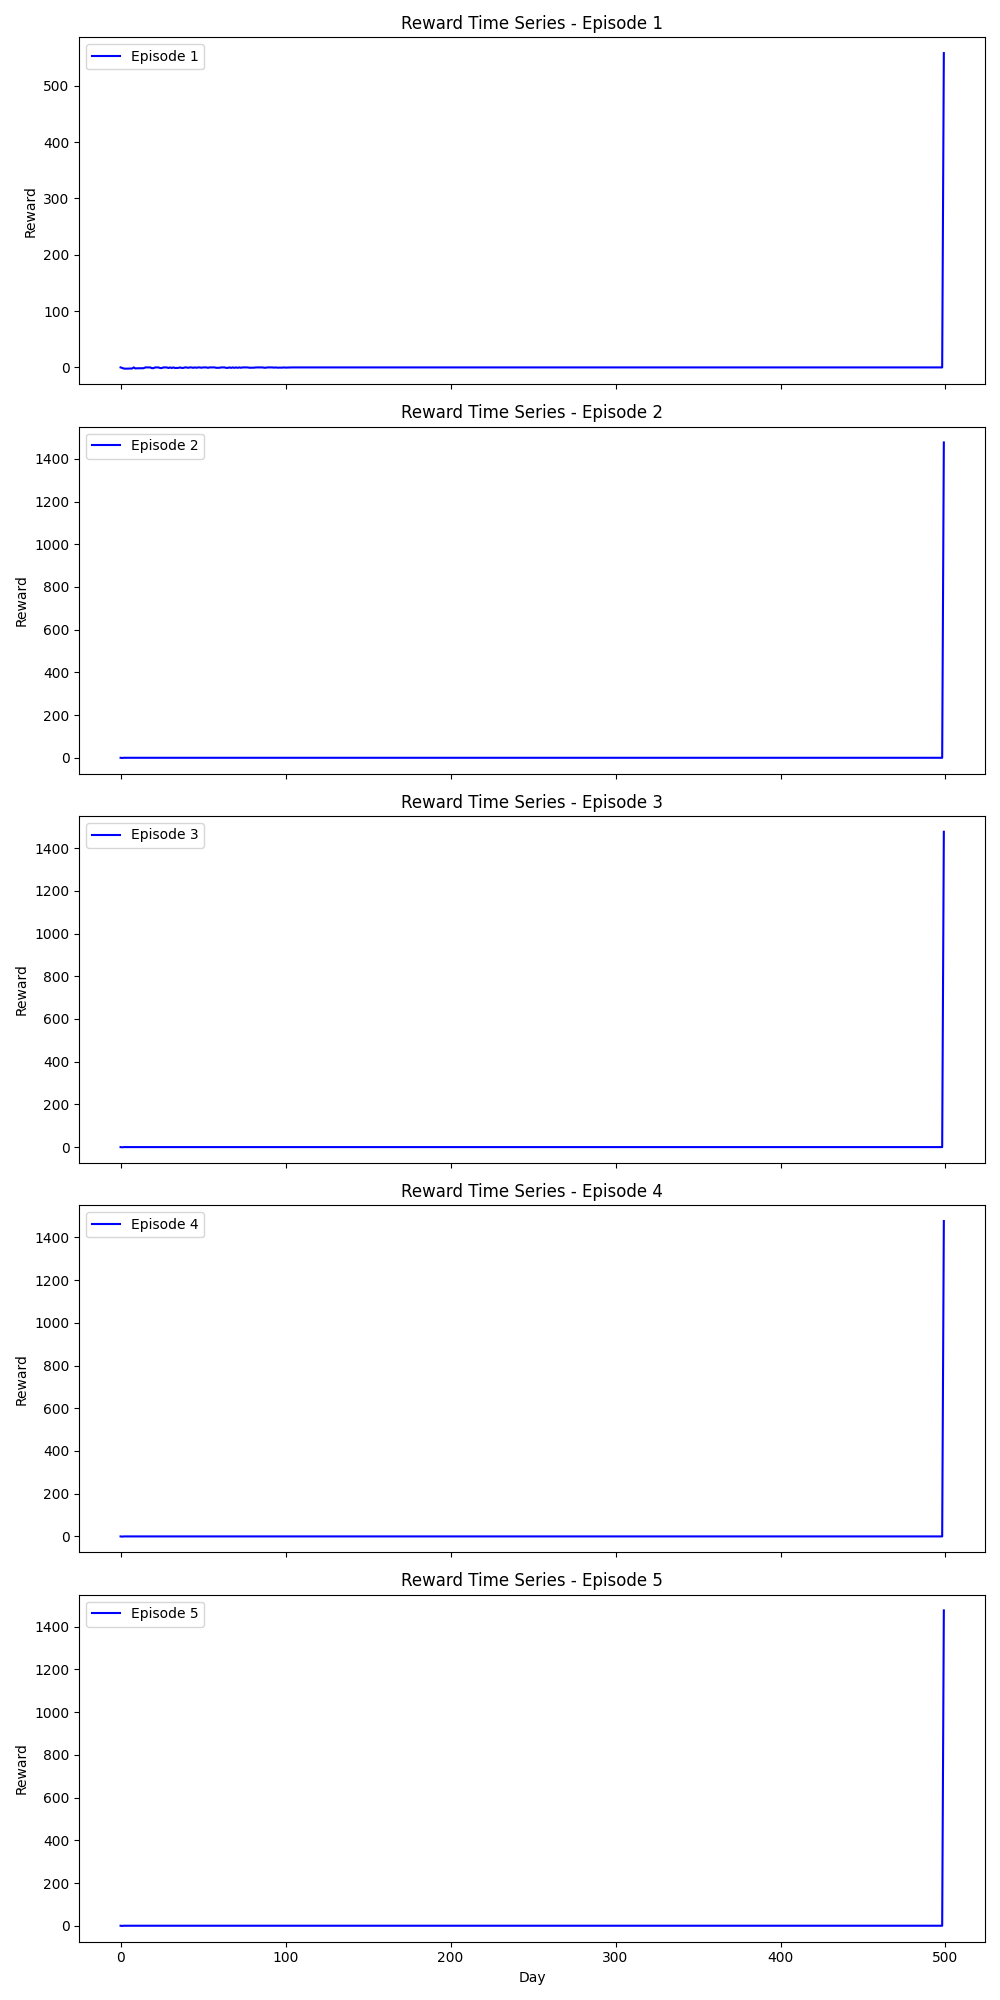

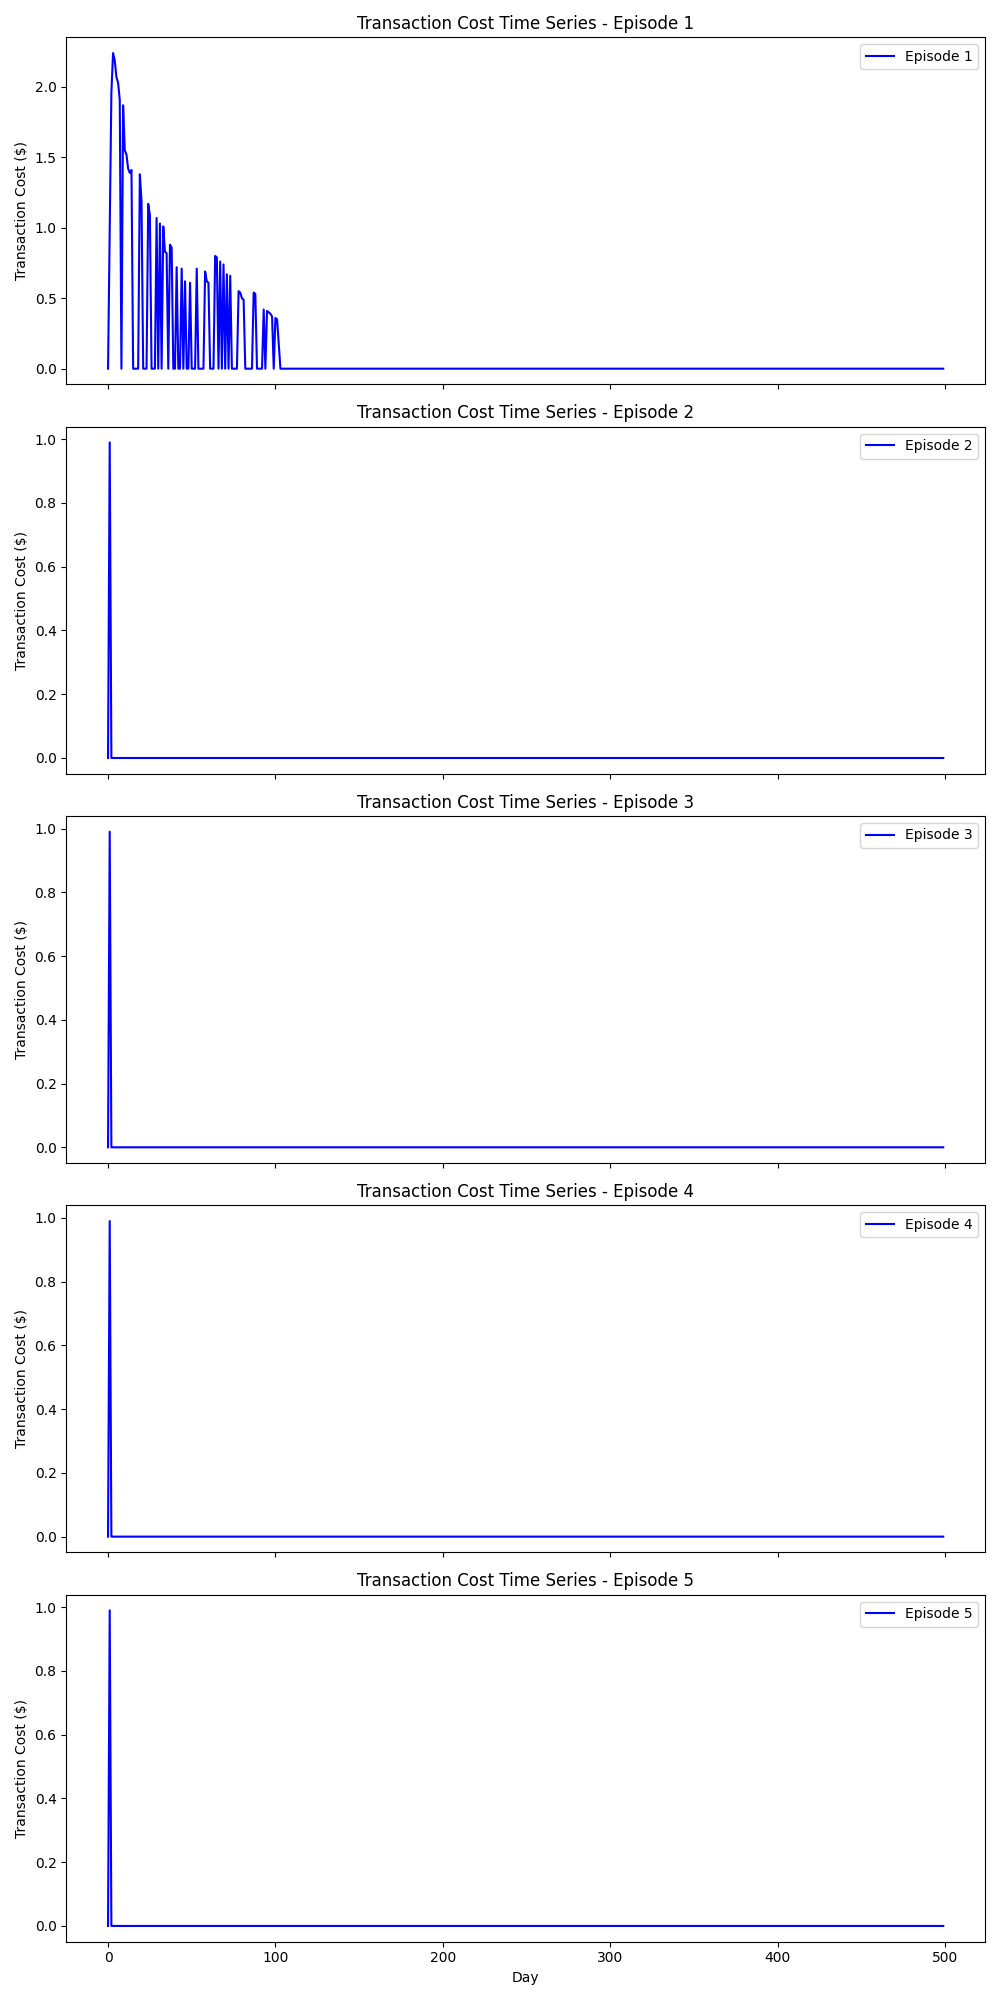

In [14]:
from IPython.display import display
from PIL import Image

display(Image.open("portfolio_value.png"))
display(Image.open("portfolio_return.png"))
display(Image.open("reward.png"))
display(Image.open("transaction_cost.png"))
